**Phase 1: Web Scraping (Data Collection)**

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import plotly.express as px
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import logging
import random
from datetime import datetime

In [ ]:
# 1. LOGGING
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(message)s',
    handlers=[logging.FileHandler("gutenberg_detailed.log"), logging.StreamHandler()]
)

class GutenbergScraper:
    def __init__(self, target_count=5000):
        self.target_count = target_count
        self.base_url = "https://www.gutenberg.org"
        self.search_url = "https://www.gutenberg.org/ebooks/search/?sort_order=downloads"
        self.headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'}
        self.data = []

    def fetch(self, url):
        try:
            time.sleep(random.uniform(0.8, 1.5)) # Respectful delay
            resp = requests.get(url, headers=self.headers, timeout=15)
            resp.raise_for_status()
            return BeautifulSoup(resp.text, 'html.parser')
        except Exception as e:
            logging.error(f"Request failed: {e}")
            return None

    def scrape(self):
        start_index = 1
        logging.info("Starting Scraper...")

        while len(self.data) < self.target_count:
            # Handle Pagination (Requirement)
            current_search_url = f"{self.search_url}&start_index={start_index}"
            soup = self.fetch(current_search_url)
            if not soup: break

            # Find all book links on the search page
            book_links = soup.select('li.booklink a.link')
            if not book_links: break

            for link in book_links:
                if len(self.data) >= self.target_count: break

                book_url = self.base_url + link.get('href')
                self.parse_book_page(book_url)

            logging.info(f"Progress: {len(self.data)} / {self.target_count}")
            start_index += 25 # Next page index

        self.save()

    def parse_book_page(self, url):
        soup = self.fetch(url)
        if not soup: return

        try:
            # Metadata table parsing
            bibrec = soup.find('table', class_='bibrec')
            meta = {row.th.text.strip(): row.td.text.strip() for row in bibrec.find_all('tr') if row.th and row.td}

            record = {
                'Title': soup.find('h1', itemprop='name').text.strip() if soup.find('h1') else "N/A",
                'Author': meta.get('Author', 'Unknown'),
                'Language': meta.get('Language', 'N/A'),
                'Subject': meta.get('Subject', 'N/A').replace('\n', ' '),
                'Category': meta.get('Category', 'Books'),
                'Release_Date': meta.get('Release Date', 'N/A'),
                'Downloads': soup.find('td', itemprop='interactionCount').text.split()[0] if soup.find('td', itemprop='interactionCount') else "0",
                'Source_URL': url,
                'Scrape_Timestamp': datetime.now().strftime("%Y-%m-%d %H:%M")
            }
            self.data.append(record)
        except Exception as e:
            logging.warning(f"Parsing error at {url}: {e}")

    def save(self):
        if self.data:
            df = pd.DataFrame(self.data)
            df.to_csv("gutenberg_raw_5000.csv", index=False, encoding='utf-8-sig')
            logging.info(f"Saved {len(df)} records to gutenberg_raw_5000.csv")

if __name__ == "__main__":
    scraper = GutenbergScraper(target_count=5000)
    scraper.scrape()

**Phase 2: Data Cleaning & Transformation**

In [ ]:
# 1. Load data
df = pd.read_csv('gutenberg_raw_5000.csv')
before_df = df.copy()

# 2. Handle missing values
# Author: label as Unknown. Release_Date/Title: drop critical missing
df['Author'] = df['Author'].fillna('Unknown')
df.dropna(subset=['Release_Date', 'Title'], inplace=True)

# 3. Deduplication
# Logic: Same Title + Author = Duplicate
df.drop_duplicates(subset=['Title', 'Author'], keep='first', inplace=True)

# 4. Standardize types & Text normalization
df['Downloads'] = pd.to_numeric(df['Downloads'], errors='coerce').fillna(0)
df['Release_Date_Clean'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Language'] = df['Language'].str.strip()
df['Category'] = df['Category'].str.lower().str.strip()

# 5. Outliers (IQR Method)
# Identify but keep genuine extremes (mega-hits)
Q1, Q3 = df['Downloads'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df['Is_Outlier'] = df['Downloads'] > (Q3 + 1.5 * IQR)

# 6. Feature Engineering (5 columns)
df['Year'] = df['Release_Date_Clean'].dt.year
df['Days_Online'] = (pd.Timestamp.now() - df['Release_Date_Clean']).dt.days
df['Title_Length'] = df['Title'].apply(lambda x: len(str(x).split()))
df['Tier'] = pd.qcut(df['Downloads'], q=4, labels=['Bronze', 'Silver', 'Gold', 'Platinum'])
df['Author_Clean'] = df['Author'].str.split(',').str[0]

# 7. Export and Comparison
df.to_csv('gutenberg_cleaned.csv', index=False)

print("--- Comparison Table ---")
comparison = pd.DataFrame({
    "Metric": ["Rows", "Cols", "Null Downloads"],
    "Before": [before_df.shape[0], before_df.shape[1], before_df['Downloads'].isna().sum()],
    "After": [df.shape[0], df.shape[1], df['Downloads'].isna().sum()]
})
print(comparison)

--- Comparison Table ---
           Metric  Before  After
0            Rows    5000   4853
1            Cols       9     16
2  Null Downloads       0      0


**Phase 3: Exploratory Data Analysis (EDA)**

In [ ]:
# 1. LOAD DATA
df = pd.read_csv('gutenberg_cleaned.csv')

# 2. DESCRIPTIVE STATISTICS
# Mean, median, mode, and quartiles
numeric_summary = df[['Downloads', 'Days_Online', 'Title_Length']].describe()
numeric_summary.loc['mode'] = df[['Downloads', 'Days_Online', 'Title_Length']].mode().iloc[0]
print("--- 1. Stats ---\n", numeric_summary)

# 3. SKEWNESS
# Check data distribution
skewness = df[['Downloads', 'Days_Online', 'Title_Length']].skew()
print("\n--- 2. Skewness ---\n", skewness)

# 4. CORRELATION
# Relationship strength between variables
corr_matrix = df[['Downloads', 'Days_Online', 'Title_Length']].corr()
print("\n--- 3. Correlation ---\n", corr_matrix)

# 5. GROUP-BY
# Performance by Tier
tier_perf = df.groupby('Tier')['Downloads'].mean()
print("\n--- 4. Mean Downloads by Tier ---\n", tier_perf)

# 6. TOP RECORDS
# Identify 5 most popular books
top_books = df.nlargest(5, 'Downloads')[['Title', 'Author_Clean', 'Downloads']]
print("\n--- 5. Top 5 Books ---\n", top_books)

# 7. HYPOTHESES
print("\n--- 6. Hypothesis Testing ---")

# H1: English books popularity
eng = df[df['Language'] == 'English']['Downloads']
others = df[df['Language'] != 'English']['Downloads']
t_stat, p1 = stats.ttest_ind(eng, others, equal_var=False)
print(f"H1 (English vs Others): {'Confirmed' if p1 < 0.05 else 'Rejected'} (p={p1:.4f})")

# H2: Title length vs Downloads
corr_t, p2 = stats.pearsonr(df['Title_Length'], df['Downloads'])
print(f"H2 (Title Length): {'Confirmed' if p2 < 0.05 else 'Rejected'} (Corr={corr_t:.4f})")

# H3: Longevity (Age) vs Downloads
corr_a, p3 = stats.pearsonr(df['Days_Online'], df['Downloads'])
print(f"H3 (Longevity): {'Confirmed' if p3 < 0.05 else 'Rejected'} (Corr={corr_a:.4f})")

# 8. TIME ANALYSIS
# Average popularity by Year
yearly_trend = df.groupby('Year')['Downloads'].mean()
print("\n--- 7. Yearly Trends ---\n", yearly_trend.tail(5))

--- 1. Stats ---
            Downloads   Days_Online  Title_Length
count    4853.000000   4853.000000   4853.000000
mean     6000.973831   5516.113744      9.757264
std      6452.678152   2456.191414      3.032255
min      2756.000000     12.000000      1.000000
25%      3357.000000   4066.000000      7.000000
50%      4197.000000   6320.000000     10.000000
75%      6406.000000   6867.000000     12.000000
max    146193.000000  19868.000000     18.000000
mode     2988.000000   6202.000000      9.000000

--- 2. Skewness ---
 Downloads       9.125879
Days_Online    -0.296729
Title_Length    0.097962
dtype: float64

--- 3. Correlation ---
               Downloads  Days_Online  Title_Length
Downloads      1.000000     0.147418     -0.046835
Days_Online    0.147418     1.000000     -0.213344
Title_Length  -0.046835    -0.213344      1.000000

--- 4. Mean Downloads by Tier ---
 Tier
Bronze       3030.752883
Gold         5057.836079
Platinum    12170.073432
Silver       3753.544930
Name: Down

**Phase 4: Data Visualization**

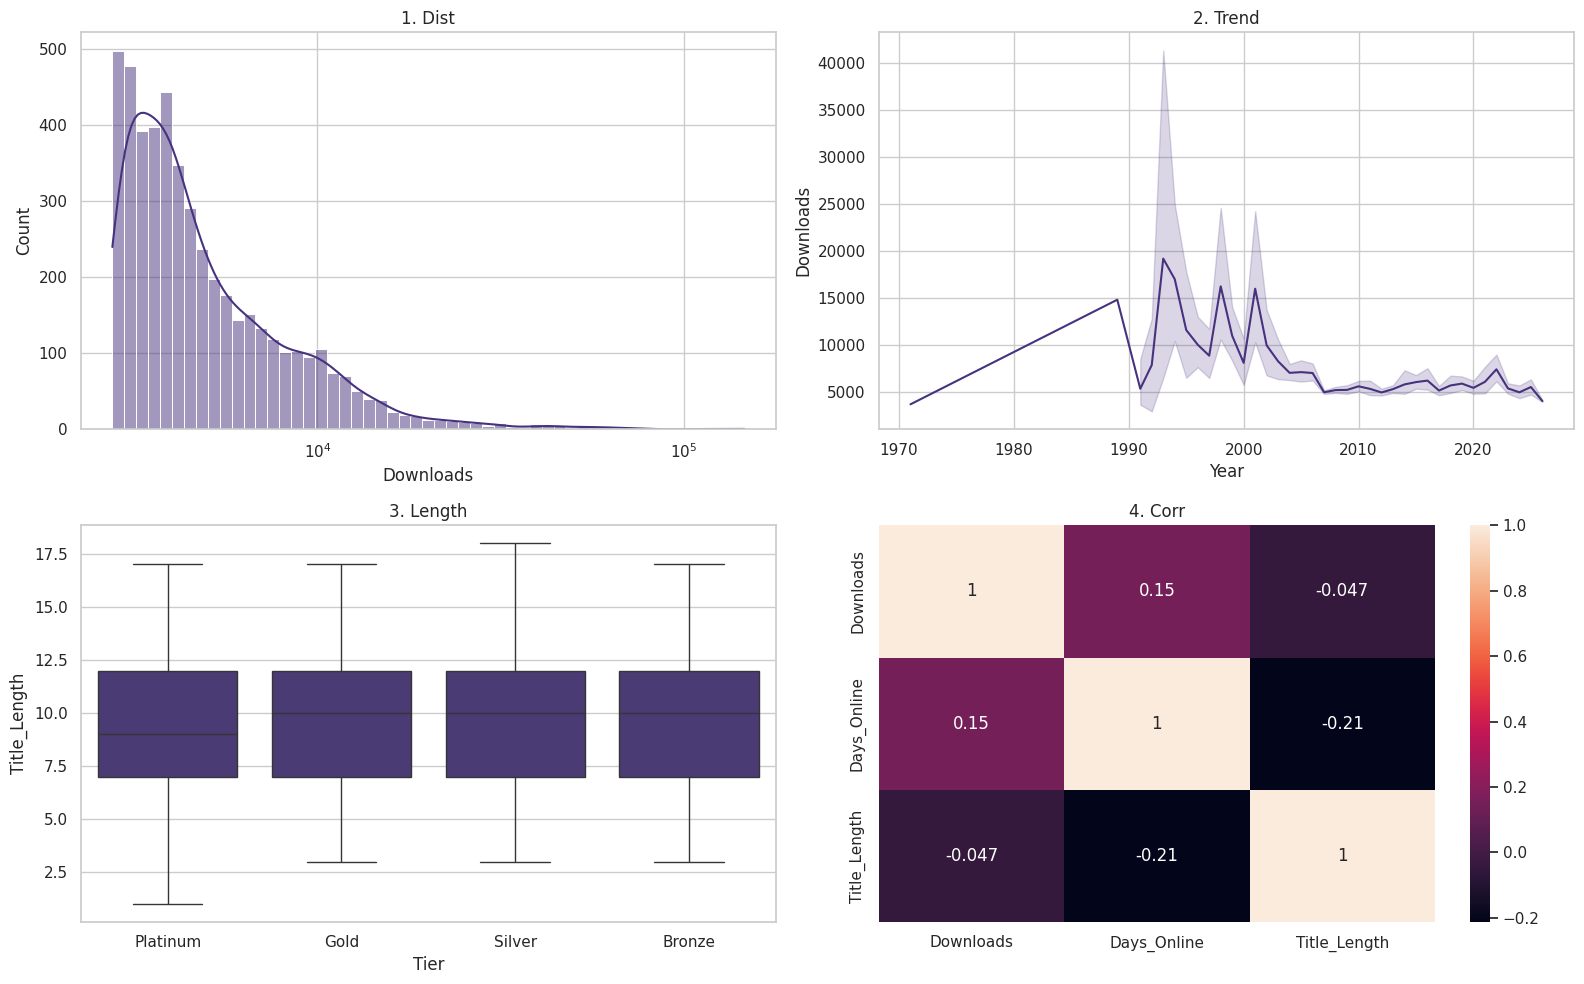

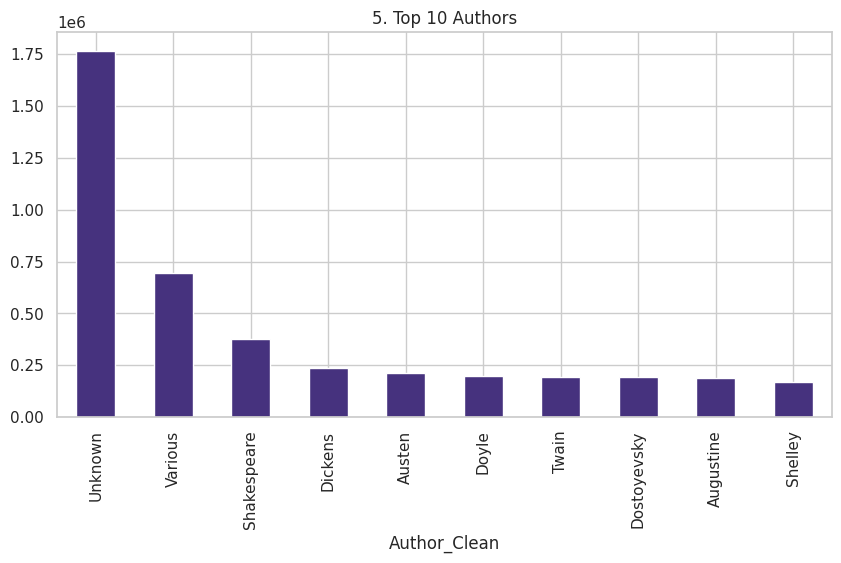

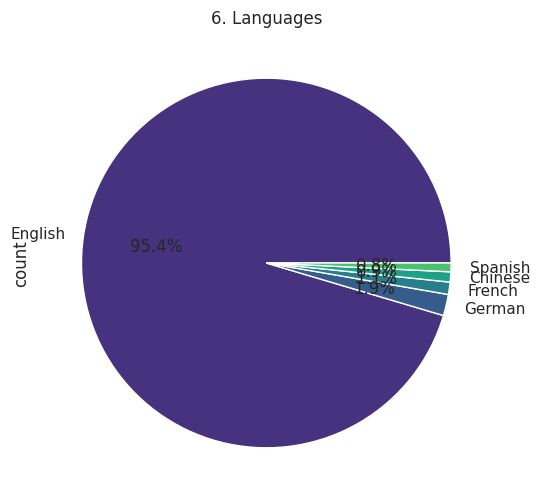

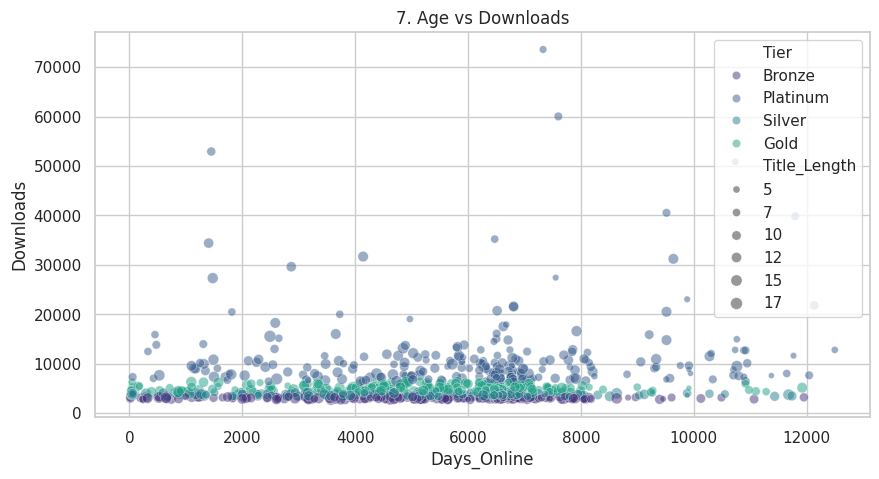

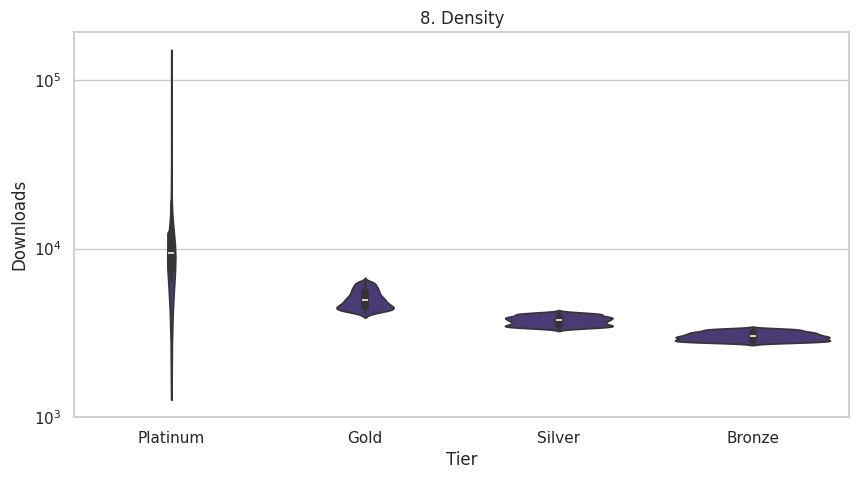

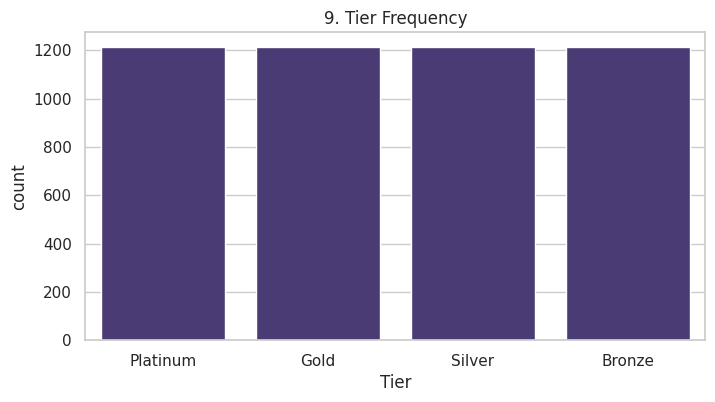

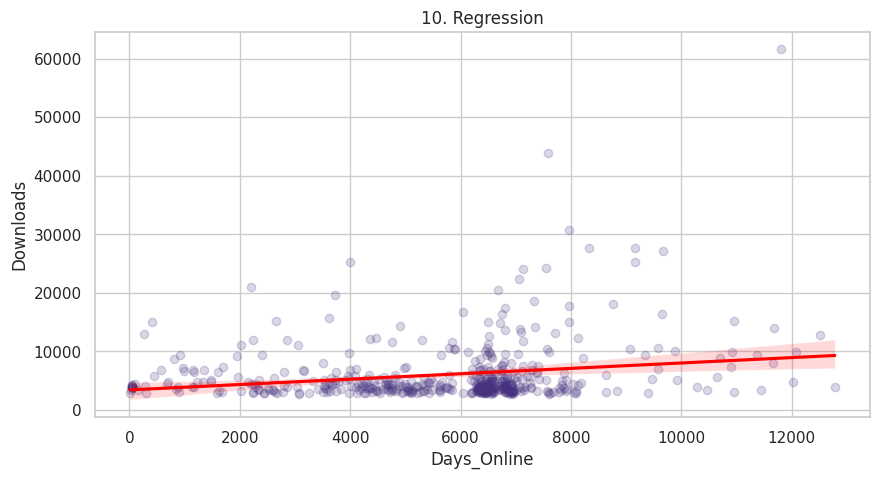

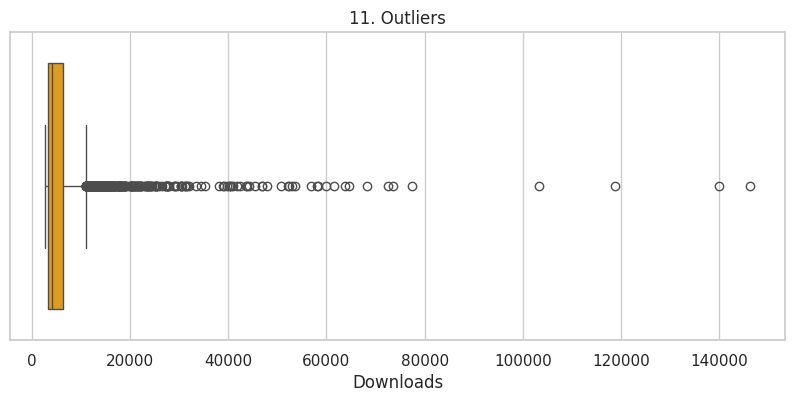

In [ ]:
# 1. Setup
df = pd.read_csv('gutenberg_cleaned.csv')
sns.set_theme(style="whitegrid", palette="viridis")
main_color = sns.color_palette("viridis")[0]

# --- STATIC VISUALIZATIONS ---

# 1-4. Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
# 1. Dist: Shows most books have average hits; only a few are mega-popular.
sns.histplot(df['Downloads'], kde=True, ax=axes[0,0], log_scale=True).set_title('1. Dist')
# 2. Trend: Visualizes how popularity changes based on the book's release year.
sns.lineplot(data=df, x='Year', y='Downloads', ax=axes[0,1]).set_title('2. Trend')
# 3. Length: Compares title word counts across different popularity groups.
sns.boxplot(x='Tier', y='Title_Length', data=df, ax=axes[1,0]).set_title('3. Length')
# 4. Corr: Quantifies the mathematical relationship between age, size, and hits.
sns.heatmap(df[['Downloads', 'Days_Online', 'Title_Length']].corr(), annot=True, ax=axes[1,1]).set_title('4. Corr')
plt.tight_layout()
plt.show()

# 5. Top Authors: Identifies authors who drive the most traffic to the library.
plt.figure(figsize=(10, 5))
df.groupby('Author_Clean')['Downloads'].sum().nlargest(10).plot(kind='bar', color=main_color)
plt.title('5. Top 10 Authors')
plt.show()

# 6. Languages: Shows the dominance of English compared to other languages.
plt.figure(figsize=(6, 6))
df['Language'].value_counts().nlargest(5).plot(kind='pie', autopct='%1.1f%%')
plt.title('6. Languages')
plt.show()

# 7. Multi-variable Scatter: Encodes Age, Hits, Tier, and Title size in one view.
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df.sample(1000), x='Days_Online', y='Downloads', hue='Tier', size='Title_Length', alpha=0.5)
plt.title('7. Age vs Downloads')
plt.show()

# 8. Violin Plot: Shows the probability density of downloads per category.
plt.figure(figsize=(10, 5))
sns.violinplot(x='Tier', y='Downloads', data=df)
plt.yscale('log')
plt.title('8. Density')
plt.show()

# 9. Tier Count: Verification that the dataset is split into equal popularity quartiles.
plt.figure(figsize=(8, 4))
sns.countplot(x='Tier', data=df)
plt.title('9. Tier Frequency')
plt.show()

# 10. Regression: Proves that older books accumulate more downloads over time.
plt.figure(figsize=(10, 5))
sns.regplot(data=df.sample(500), x='Days_Online', y='Downloads', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('10. Regression')
plt.show()

# 11. Outliers: Highlights specific "mega-hits" that exist outside the normal range.
plt.figure(figsize=(10, 4))
sns.boxplot(x='Downloads', data=df, color='orange')
plt.title('11. Outliers')
plt.show()

# --- INTERACTIVE ---

# 12. Top Books: Interactive ranking of the most downloaded individual titles.
fig1 = px.bar(df.nlargest(10, 'Downloads'), x='Title', y='Downloads', color='Author_Clean', title='12. Top 10 Books')
fig1.show()

# 13. Map: Exploratory tool to find specific books by hovering over data points.
fig2 = px.scatter(df.sample(1000), x='Days_Online', y='Downloads', color='Language', hover_data=['Title'], title='13. Age Map')
fig2.show()

# 14. Donut: Interactive breakdown of the four popularity segments.
fig3 = px.pie(df, names='Tier', hole=0.4, title='14. Tiers')
fig3.show()